In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

from tqdm import tqdm

In [ ]:
df = pd.read_csv("../train.csv")

# train_df, val_df = train_test_split(
#     df,
#     test_size=0.2,
#     stratify=df["pen_id"],
#     random_state=41
# )

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)

train_idx, val_idx = next(gss.split(df, groups=df["writer_id"]))

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

print(len(train_df), len(val_df))

33200 7050


In [3]:
class PenDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image_path"])
        
        image = Image.open(img_path).convert("RGB")   # grayscale
        label = int(row["pen_id"]) - 1  # 0-based
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [4]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
    224,
    scale=(0.7, 1.0)
),   # reduce slightly
    transforms.RandomRotation(10),
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=0,
            translate=(0.05, 0.05)
        )
    ], p=0.5),
    transforms.ColorJitter(contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
root_dir = "../"

train_dataset = PenDataset(train_df, root_dir, train_transform)
val_dataset = PenDataset(val_df, root_dir, val_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=8)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
model = models.resnet50(weights='ResNet50_Weights.DEFAULT')
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 8)
)

model = model.to(device)

In [ ]:
# # Freeze everything first
# for param in model.parameters():
#     param.requires_grad = False

# # Unfreeze last block (layer4)
# for param in model.layer4.parameters():
#     param.requires_grad = True

# # Unfreeze classifier
# for param in model.fc.parameters():
#     param.requires_grad = True

In [ ]:
# weights = torch.ones(8)
# weights[2] = 1.5
# weights[6] = 1.5
# weights[7] = 1.5

# weights = weights.to(device)

# criterion = nn.CrossEntropyLoss(weight=weights,label_smoothing=0.1)

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=5e-4)
# optimizer = optim.Adam(model.fc.parameters(), lr=3e-4, weight_decay=5e-4)
# optimizer = optim.Adam(
#     list(model.layer4.parameters()) + list(model.fc.parameters()),
#     lr=2e-4,
#     weight_decay=5e-4
# )

In [9]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10   # number of epochs for one cycle
)

In [10]:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     model.train()
#     total_loss = 0

#     for images, labels in tqdm(loader):
#         images, labels = images.to(device), labels.to(device)

#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     return total_loss / len(loader)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return total_loss / len(loader), acc

In [11]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="macro")
    rec = recall_score(all_labels, all_preds, average="macro")

    return total_loss / len(loader), acc, prec, rec

In [13]:
num_epochs = 20
patience = 3

best_val_loss = float("inf")
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_prec, val_rec = evaluate(model, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val Precision: {val_prec:.4f} | Val Recall: {val_rec:.4f}")
    scheduler.step()
    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model_resnet50.pth")
        print("✅ Best model saved")

    else:
        counter += 1
        print(f"Early stopping counter: {counter}/{patience}")

        if counter >= patience:
            print("⛔ Early stopping triggered")
            break


Epoch 1/20


100%|██████████| 260/260 [02:42<00:00,  1.60it/s]


Train Loss: 0.7362 | Val Loss: 0.8560 | Train Acc: 0.8583 | Val Acc: 0.8204 | Val Precision: 0.8635 | Val Recall: 0.8235
✅ Best model saved

Epoch 2/20


100%|██████████| 260/260 [02:41<00:00,  1.61it/s]


Train Loss: 0.6651 | Val Loss: 0.7578 | Train Acc: 0.8984 | Val Acc: 0.8696 | Val Precision: 0.8797 | Val Recall: 0.8648
✅ Best model saved

Epoch 3/20


...

Train Loss: 0.5469 | Val Loss: 0.7204 | Train Acc: 0.9673 | Val Acc: 0.8997 | Val Precision: 0.8997 | Val Recall: 0.8991
Early stopping counter: 1/3

Epoch 9/20


100%|██████████| 260/260 [02:42<00:00,  1.60it/s]


Train Loss: 0.5333 | Val Loss: 0.7321 | Train Acc: 0.9746 | Val Acc: 0.8989 | Val Precision: 0.9002 | Val Recall: 0.8957
Early stopping counter: 2/3

Epoch 10/20


100%|██████████| 260/260 [02:41<00:00,  1.61it/s]


Train Loss: 0.5235 | Val Loss: 0.7249 | Train Acc: 0.9803 | Val Acc: 0.9050 | Val Precision: 0.9057 | Val Recall: 0.9026
Early stopping counter: 3/3
⛔ Early stopping triggered


In [14]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
from tqdm import tqdm
import torch.nn as nn

# -----------------------
# Load test CSV
# -----------------------
test_df = pd.read_csv("../test.csv")

# -----------------------
# Dataset (no labels)
# -----------------------
class TestDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image_path"])
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, row["image_id"]

# -----------------------
# Transform (same as val)
# -----------------------
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
        transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

# -----------------------
# DataLoader
# -----------------------
test_dataset = TestDataset(test_df, "", test_transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=8)

# -----------------------
# Load model
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights='ResNet50_Weights.DEFAULT')
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 8)
)

# model = model.to(device)

model.load_state_dict(torch.load("best_model_resnet50.pth", map_location=device))
model = model.to(device)
model.eval()

# -----------------------
# Inference
# -----------------------
predictions = []
image_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader):
        images = images.to(device)

        outputs = model(images)
        flipped_images = torch.flip(images, dims=[3])
        outputs_flipped = model(flipped_images)

        flipped_v = torch.flip(images, dims=[2])
        outputs_v = model(flipped_v)

        outputs = (outputs + outputs_flipped + outputs_v) / 3
        # outputs = (outputs + outputs_flipped) / 2
        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        image_ids.extend(ids)

# -----------------------
# Convert back to 1-based labels
# -----------------------
predictions = [p + 1 for p in predictions]

# -----------------------
# Create submission
# -----------------------
submission = pd.DataFrame({
    "image_id": image_ids,
    "pen_id": predictions
})

submission.to_csv("submission_resnet50.csv", index=False)

print("✅ submission.csv saved")

100%|██████████| 47/47 [00:27<00:00,  1.73it/s]


✅ submission.csv saved


In [13]:
from sklearn.metrics import confusion_matrix

def get_predictions(model, loader, device):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet34(weights='ResNet34_Weights.DEFAULT')
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 8)
)

# model = model.to(device)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model = model.to(device)

In [16]:
y_true, y_pred = get_predictions(model, val_loader, device)

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[899   0   1   0   0   0   0   0]
 [  0 850   0   0   0   0   0   0]
 [  0   0 591   0   0   0 155  54]
 [  0   0   0 850   0   0   0   0]
 [  0   0  36   0 900   0  13   1]
 [  0   2   0   0   0 898   0   0]
 [100   0 227   0   0   0 533  40]
 [  0   0  39   0   0   0  24 837]]


In [18]:
!pip install seaborn 

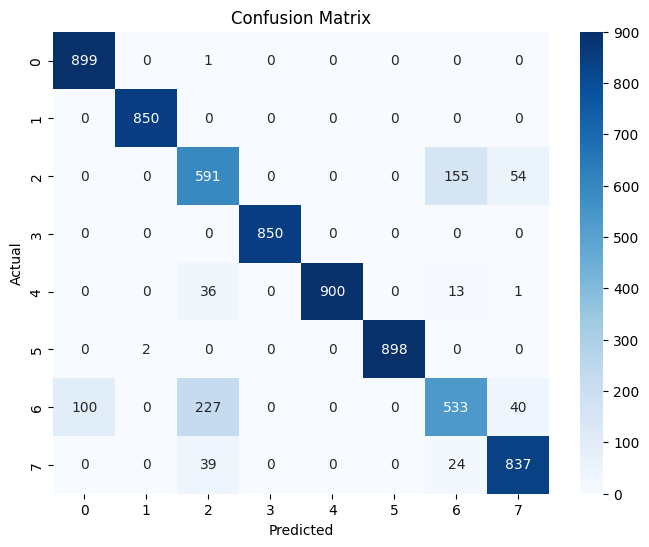

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

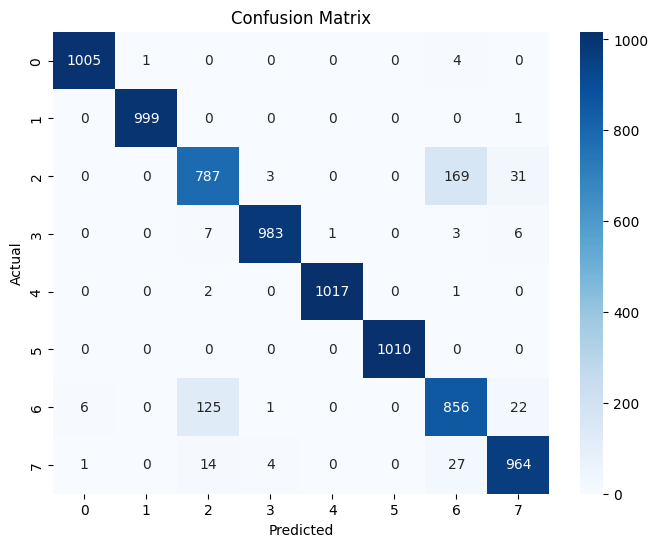

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()